# NND singular-value samples

This notebook samples singular values from the Nuclear Norm Distribution (NND) joint density

$$
p(s_1, \dots, s_n) \propto
\prod_{i=1}^n s_i^{m-n} e^{-\eta s_i}
\prod_{1 \le i < j \le n} |s_i^2 - s_j^2|,
\qquad s_i > 0,
$$

for fixed `n = 50` and `m in {50, 100, 250, 500}`.  The sampler works in log singular values, so the target includes the change-of-variables Jacobian.  Samples are sorted descending only for plotting.

In [1]:
from pathlib import Path

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from numpyro.infer import MCMC, NUTS

print("JAX devices:", jax.devices())
assert jax.default_backend() == "gpu", f"Expected GPU backend, got {jax.default_backend()}"

plt.rcParams.update({
    "figure.dpi": 140,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "legend.frameon": False,
})

/home/david/venvs/jax/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX devices: [CudaDevice(id=0)]


In [2]:
# Experiment settings.
N = 50
M_VALUES = [50, 100, 250, 500]
ETA = 1.0

# Increase these for smoother figures; lower them for a quick smoke run.
NUM_WARMUP = 800
NUM_SAMPLES = 600
SEED = 20260621

# Cache avoids re-running MCMC every time the notebook is reopened.
FORCE_RESAMPLE = False
OUT_DIR = Path("paper") if Path("paper").exists() else Path(".")
CACHE_PATH = OUT_DIR / f"nnd_sv_samples_n{N}_eta{ETA:g}.npz"
CACHE_PATH

PosixPath('nnd_sv_samples_n50_eta1.npz')

## Sampler

For `y_i = log(s_i)`, the log density is

$$
\log p(y) = (m-n+1)\sum_i y_i - \eta\sum_i e^{y_i}
+ \sum_{i<j}\log|e^{2y_i} - e^{2y_j}| + C,
$$

where the extra `+1` in the first coefficient is the Jacobian from `s` to `y`.  The Vandermonde term is evaluated with a stable `log(abs(exp(a) - exp(b)))` identity.

In [3]:
def _log_abs_exp_diff(a, b):
    """Stable log(abs(exp(a) - exp(b))) for pairwise vectors."""
    delta = jnp.abs(a - b)
    return jnp.maximum(a, b) + jnp.log1p(-jnp.exp(-delta))


def nnd_log_density_y(y, *, m, n=N, eta=ETA):
    """Unnormalized log density for y = log singular values."""
    s = jnp.exp(y)
    log_s2 = 2.0 * y
    i, j = jnp.triu_indices(n, k=1)
    log_vandermonde = jnp.sum(_log_abs_exp_diff(log_s2[i], log_s2[j]))
    return (m - n + 1.0) * jnp.sum(y) - eta * jnp.sum(s) + log_vandermonde


def make_potential_fn(m, *, n=N, eta=ETA):
    def potential_fn(params):
        return -nnd_log_density_y(params["y"], m=m, n=n, eta=eta)
    return potential_fn


def sample_nnd_singular_values(m, *, n=N, eta=ETA, num_warmup=NUM_WARMUP, num_samples=NUM_SAMPLES, seed=SEED):
    rng = np.random.default_rng(seed + m)
    init_s = np.sort(rng.gamma(shape=m - n + 1, scale=1.0 / eta, size=n))[::-1]  # iid gamma + sort approx
    init_s = np.maximum(init_s, np.finfo(float).tiny)
    init_y = jnp.asarray(np.log(init_s))

    kernel = NUTS(
        potential_fn=make_potential_fn(m, n=n, eta=eta),
        dense_mass=False,
        target_accept_prob=0.85,
    )
    mcmc = MCMC(
        kernel,
        num_warmup=num_warmup,
        num_samples=num_samples,
        num_chains=1,
        progress_bar=True,
    )
    mcmc.run(jax.random.PRNGKey(seed + 10_000 + m), init_params={"y": init_y})
    y_samples = np.asarray(mcmc.get_samples()["y"])
    sv_samples = np.sort(np.exp(y_samples), axis=1)[:, ::-1]
    diagnostics = {
        "num_divergent": int(np.asarray(mcmc.get_extra_fields()["diverging"]).sum()),
    }
    return sv_samples, diagnostics

In [4]:
def load_cached_samples(path=CACHE_PATH):
    if not path.exists():
        return None
    data = np.load(path, allow_pickle=False)
    meta_ok = (
        int(data["n"]) == N
        and np.array_equal(data["m_values"], np.asarray(M_VALUES))
        and float(data["eta"]) == float(ETA)
        and int(data["num_samples"]) == NUM_SAMPLES
    )
    if not meta_ok:
        return None
    return {int(m): data[f"m_{int(m)}"] for m in M_VALUES}


def save_cached_samples(samples_by_m, path=CACHE_PATH):
    arrays = {
        "n": np.asarray(N),
        "m_values": np.asarray(M_VALUES),
        "eta": np.asarray(ETA),
        "num_samples": np.asarray(NUM_SAMPLES),
    }
    arrays.update({f"m_{m}": samples_by_m[m] for m in M_VALUES})
    np.savez_compressed(path, **arrays)


samples_by_m = None if FORCE_RESAMPLE else load_cached_samples()
if samples_by_m is None:
    samples_by_m = {}
    diagnostics_by_m = {}
    for m in M_VALUES:
        print(f"Sampling NND singular values: n={N}, m={m}, eta={ETA}")
        samples_by_m[m], diagnostics_by_m[m] = sample_nnd_singular_values(m)
        print(f"  divergent transitions: {diagnostics_by_m[m]['num_divergent']}")
    save_cached_samples(samples_by_m)
    print(f"Saved {CACHE_PATH}")
else:
    print(f"Loaded cached samples from {CACHE_PATH}")

Loaded cached samples from nnd_sv_samples_n50_eta1.npz


In [5]:
# Compact numerical summary.
summary_rows = []
for m, samples in samples_by_m.items():
    nuc = samples.sum(axis=1)
    summary_rows.append((
        m,
        samples.shape[0],
        float(nuc.mean()),
        float(nuc.std()),
        float(samples[:, 0].mean()),
        float(samples[:, -1].mean()),
    ))

print("m    samples  E[sum s_i]   sd[sum s_i]   E[s_1]   E[s_n]")
for row in summary_rows:
    print(f"{row[0]:<4d} {row[1]:<7d} {row[2]:>11.2f} {row[3]:>13.2f} {row[4]:>8.2f} {row[5]:>8.2f}")

m    samples  E[sum s_i]   sd[sum s_i]   E[s_1]   E[s_n]
50   600         2487.96         50.61   148.15     0.26
100  600         5006.62         71.50   224.81    22.44
250  600        12524.20        113.40   426.24   118.95
500  600        25023.87        183.22   737.16   307.77


Saved figures/nnd_sv_profiles_scaled.pdf


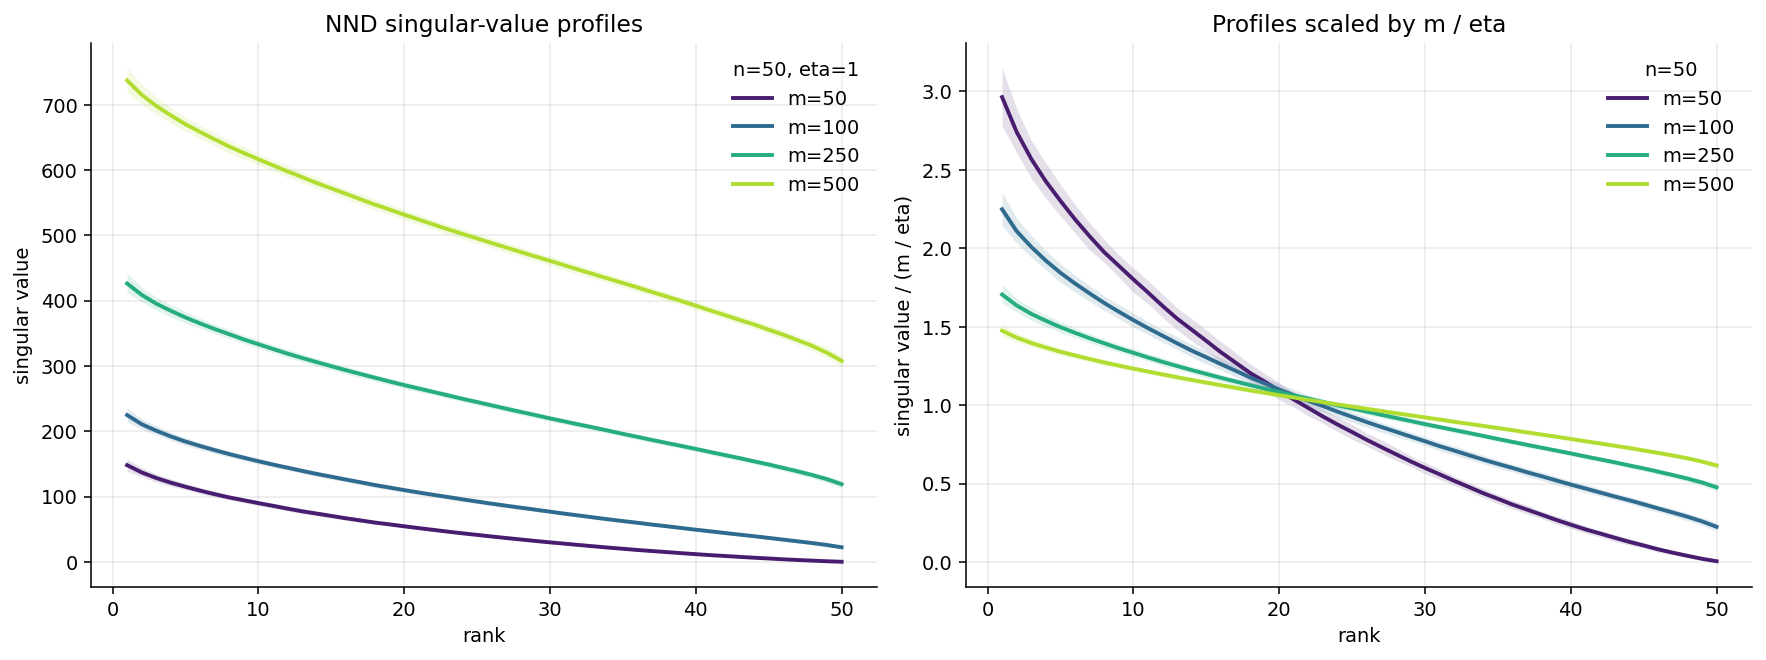

In [6]:
rank = np.arange(1, N + 1)
colors = plt.cm.viridis(np.linspace(0.08, 0.88, len(M_VALUES)))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6), constrained_layout=True)

for color, m in zip(colors, M_VALUES):
    samples = samples_by_m[m]
    mean = samples.mean(axis=0)
    lo, hi = np.quantile(samples, [0.1, 0.9], axis=0)

    axes[0].plot(rank, mean, color=color, lw=2, label=f"m={m}")
    axes[0].fill_between(rank, lo, hi, color=color, alpha=0.14, linewidth=0)

    scale = m / ETA
    axes[1].plot(rank, mean / scale, color=color, lw=2, label=f"m={m}")
    axes[1].fill_between(rank, lo / scale, hi / scale, color=color, alpha=0.14, linewidth=0)

axes[0].set_title("NND singular-value profiles")
axes[0].set_xlabel("rank")
axes[0].set_ylabel("singular value")
axes[0].legend(title=f"n={N}, eta={ETA:g}")

axes[1].set_title("Profiles scaled by m / eta")
axes[1].set_xlabel("rank")
axes[1].set_ylabel("singular value / (m / eta)")
axes[1].legend(title=f"n={N}")

scaled_pdf_path = OUT_DIR / "figures" / "nnd_sv_profiles_scaled.pdf"
scaled_pdf_path.parent.mkdir(parents=True, exist_ok=True)
fig_scaled, ax_scaled = plt.subplots(figsize=(4.0, 3.0), constrained_layout=True)
for color, m in zip(colors, M_VALUES):
    samples = samples_by_m[m]
    mean = samples.mean(axis=0)
    lo, hi = np.quantile(samples, [0.1, 0.9], axis=0)
    scale = m / ETA
    ax_scaled.plot(rank, mean / scale, color=color, lw=2, label=f"m={m}")
    ax_scaled.fill_between(rank, lo / scale, hi / scale, color=color, alpha=0.14, linewidth=0)
ax_scaled.set_xlabel("rank")
ax_scaled.set_ylabel("singular value / (m / eta)")
ax_scaled.legend(title=f"n={N}")
fig_scaled.savefig(scaled_pdf_path, bbox_inches="tight")
plt.close(fig_scaled)
print(f"Saved {scaled_pdf_path}")

plt.show()

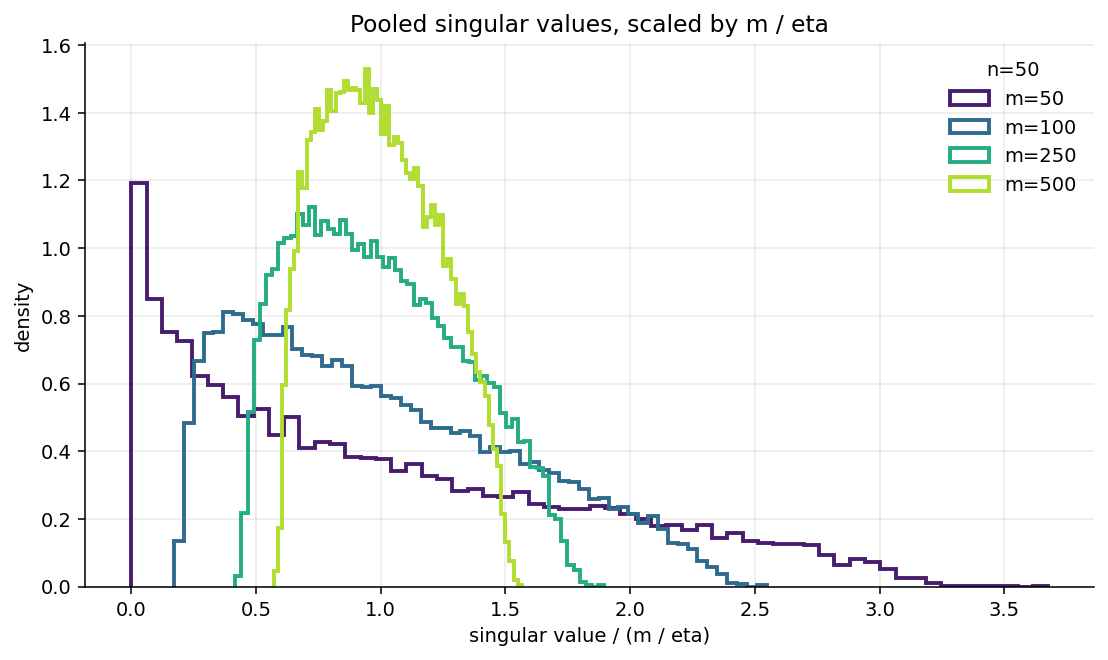

In [7]:
fig, ax = plt.subplots(figsize=(7.8, 4.6), constrained_layout=True)

for color, m in zip(colors, M_VALUES):
    pooled = (samples_by_m[m] / (m / ETA)).ravel()
    ax.hist(
        pooled,
        bins=60,
        density=True,
        histtype="step",
        linewidth=2,
        color=color,
        label=f"m={m}",
    )

ax.set_title("Pooled singular values, scaled by m / eta")
ax.set_xlabel("singular value / (m / eta)")
ax.set_ylabel("density")
ax.legend(title=f"n={N}")
plt.show()

## Optional: independent-gamma comparison

The curves below compare the full NND samples above to the independent-gamma approximation used as the initializer.  The approximation keeps the one-body term but drops the Vandermonde repulsion, so it is not the target distribution sampled above.

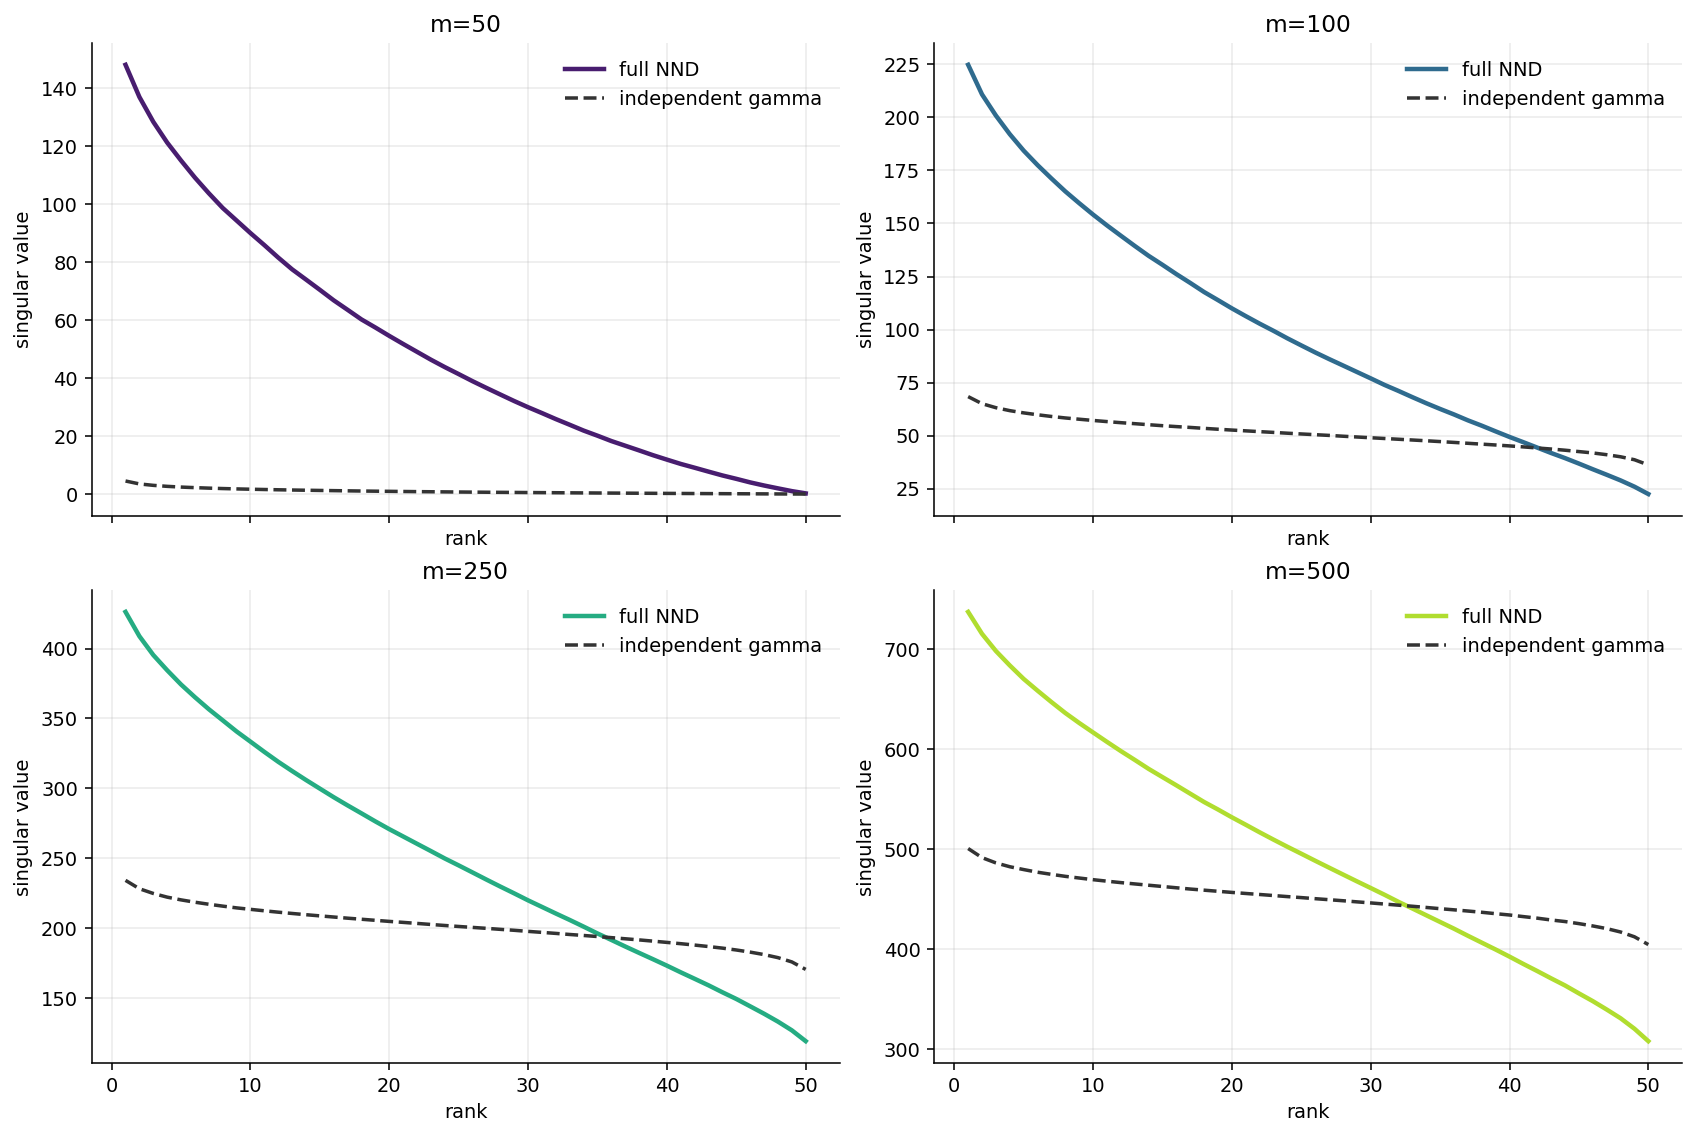

In [8]:
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(2, 2, figsize=(12.0, 8.0), constrained_layout=True, sharex=True)
axes = axes.ravel()

for ax, color, m in zip(axes, colors, M_VALUES):
    full_mean = samples_by_m[m].mean(axis=0)
    gamma_samples = np.sort(
        rng.gamma(shape=m - N + 1, scale=1.0 / ETA, size=(NUM_SAMPLES, N)),
        axis=1,
    )[:, ::-1]
    gamma_mean = gamma_samples.mean(axis=0)

    ax.plot(rank, full_mean, color=color, lw=2.3, label="full NND")
    ax.plot(rank, gamma_mean, color="0.2", lw=1.8, ls="--", label="independent gamma")
    ax.set_title(f"m={m}")
    ax.set_xlabel("rank")
    ax.set_ylabel("singular value")
    ax.legend()

plt.show()